# Analyzing and Plotting Stock Market Trends

## Description

In this project, I aim to analyze and visualize stock market trends by integrating historical stock price data with corporate revenue figures. Using the yfinance library, I extract time-series stock data, while revenue information is obtained through web scraping from public financial sources. I then employ interactive visualizations to explore correlations between stock performance and company earnings. This analytical approach not only enhances data interpretation skills but also provides practical experience in financial data extraction, cleaning, and visualization—key components of applied data science.

| **Section** | **Title**                                         | **Description**                                                                 |
|-------------|---------------------------------------------------|---------------------------------------------------------------------------------|
| Setup       | Define a Function that Makes a Graph              | Define a reusable function for plotting stock price and revenue trends.        |
| Question 1  | Use `yfinance` to Extract Tesla Stock Data        | Retrieve Tesla's historical stock data for trend analysis.                     |
| Question 2  | Use Web Scraping to Extract Tesla Revenue Data    | Scrape Tesla's quarterly revenue data from a public source.                    |
| Question 3  | Use `yfinance` to Extract GameStop Stock Data     | Collect GameStop's historical stock prices to study volatility.                |
| Question 4  | Use Web Scraping to Extract GameStop Revenue Data | Extract GameStop’s revenue figures for performance comparison.                 |
| Question 5  | Plot Tesla Stock Graph                            | Visualize Tesla’s stock price alongside its revenue trend.                     |
| Question 6  | Plot GameStop Stock Graph                         | Create a plot to compare GameStop’s stock and revenue trajectory.              |

In [ ]:
!pip install yfinance
#!pip install pandas
#!pip install requests
!pip install bs4
#!pip install plotly


In [ ]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Historical Share Price", "Historical Revenue"), vertical_spacing = .3)
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_data.Date, infer_datetime_format=True), y=stock_data.Close.astype("float"), name="Share Price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_data.Date, infer_datetime_format=True), y=revenue_data.Revenue.astype("float"), name="Revenue"), row=2, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    fig.update_layout(showlegend=False,
    height=900,
    title=stock,
    xaxis_rangeslider_visible=True)
    fig.show()

## Question 1: Use yfinance to Extract Tesla Stock Data

In [4]:
import yfinance as yf

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2: Use Webscraping to Extract Tesla Revenue Data


Use the requests library to download the webpage https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue. Save the text of the response as a variable named html_data

In [42]:
url= "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html_data=requests.get(url).text

resolve the html data using beautiful_soup

In [43]:
soup = BeautifulSoup(html_data,"html5lib")

Using beautiful soup extract the table with `Tesla Quarterly Revenue` and store it into a dataframe named `tesla_revenue`. The dataframe should have columns `Date` and `Revenue`. Make sure the comma and dollar sign is removed from the `Revenue` column. 


In [44]:
import pandas as pd
from bs4 import BeautifulSoup


soup = BeautifulSoup(html_data, "html5lib")

tables = soup.find_all("table")
for table in tables:
    headers = [th.text.strip() for th in table.find_all("th")]
    if "Tesla Quarterly Revenue (Millions of US $)" in headers:
        target_table = table
        break


rows = []
for tr in target_table.find_all("tr")[1:]:  # Skip header
    tds = tr.find_all("td")
    if len(tds) >= 2:
        date = tds[0].text.strip()
        revenue = tds[1].text.strip().replace("$", "").replace(",", "")
        if revenue:
            rows.append([date, int(revenue)])


tesla_revenue = pd.DataFrame(rows, columns=["Date", "Revenue"])
print(tesla_revenue)


          Date  Revenue
0   2024-12-31    25707
1   2024-09-30    25182
2   2024-06-30    25500
3   2024-03-31    21301
4   2023-12-31    25167
..         ...      ...
57  2010-09-30       31
58  2010-06-30       28
59  2010-03-31       21
60  2009-09-30       46
61  2009-06-30       27

[62 rows x 2 columns]


## Question 3: Use yfinance to Extract Stock Data


In [45]:
import yfinance as yf

gmstp = yf.Ticker("GME")
gme_data = gmstp.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666417,1.666417,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [46]:
gme_data.reset_index(inplace=True)
gme_data.head()



,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,3,2002-02-19 00:00:00-05:00,1.666417,1.666417,1.578047,1.607504,7410400,0.0,0.0
4,4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4: Use Webscraping to Extract GME Revenue Data

same as question 2

In [47]:


url="https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
html_data=requests.get(url).text



     


In [48]:
soup = BeautifulSoup(html_data,"html5lib")

In [49]:
gme_revenue = pd.DataFrame(rows, columns=["Date", "Revenue"])


In [50]:
# Sample: Creating gme_revenue if you have Tesla revenue or stock revenue data
gme_revenue = gme_data[['Date', 'Close']].copy()  # assuming you want Date and Close price
gme_revenue.dropna(inplace=True)
gme_revenue.tail()


,Date,Close
5836,2025-04-24 00:00:00-04:00,27.080000
5837,2025-04-25 00:00:00-04:00,27.459999
5838,2025-04-28 00:00:00-04:00,27.590000
5839,2025-04-29 00:00:00-04:00,27.260000
5840,2025-04-30 00:00:00-04:00,27.670000


## Question 5: Plot Tesla Stock Graph

specifications before the plots 

In [ ]:
revenue_data['Date'] = pd.to_datetime(revenue_data['Date'])
revenue_data['Revenue'] = pd.to_numeric(revenue_data['Revenue'], errors='coerce')
revenue_data.dropna(inplace=True)


Lets make graph first inorder to analyze the stock 

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

def make_graph(stock_data, revenue_data, title):
    # Clean and convert data
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])
    revenue_data['Date'] = pd.to_datetime(revenue_data['Date'])
    revenue_data['Revenue'] = pd.to_numeric(revenue_data['Revenue'], errors='coerce')
    revenue_data.dropna(inplace=True)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Stock Price (USD)', color='tab:blue')
    ax1.plot(stock_data['Date'], stock_data['Close'], label='Stock Price', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Revenue (Millions USD)', color='tab:red')
    ax2.plot(revenue_data['Date'], revenue_data['Revenue'], label='Revenue', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title(title)
    fig.tight_layout()
    plt.show()


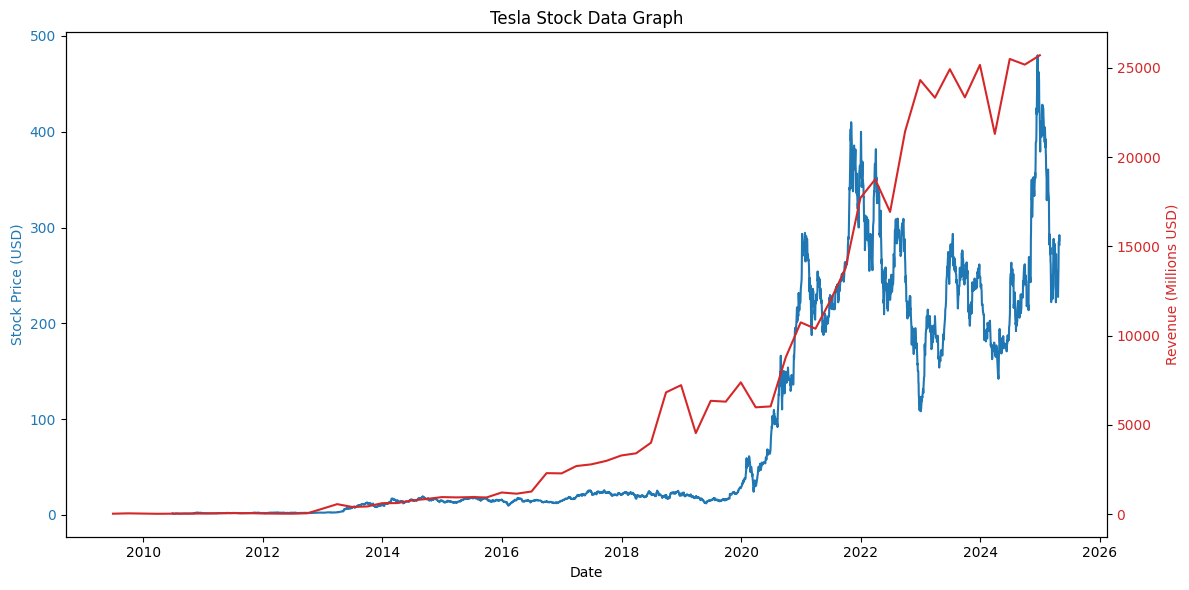

In [60]:
make_graph(tesla_data, tesla_revenue, 'Tesla Stock Data Graph')


Tesla Stock vs Revenue: A Quick Insight

From 2010 to 2019, Tesla's revenue grew slowly, and the stock price remained modest. In 2020, both surged as Tesla scaled production and EV hype soared. The peak years (2021–2022) show aligned growth in revenue and stock price. However, from 2023 onward, despite record revenues, the stock became volatile—reflecting market uncertainty, competition, and shifting investor sentiment

## Question 6: Plot GameStop Stock Graph

In [78]:
print(gme_revenue.columns)


Index(['Date', 'Close'], dtype='object')


In [80]:
gme_revenue.columns = ['Date', 'Revenue']


In [ ]:

gme_revenue.columns = ['Date', 'Revenue']


gme_data['Date'] = pd.to_datetime(gme_data['Date']).dt.tz_localize(None)
gme_revenue['Date'] = pd.to_datetime(gme_revenue['Date'])



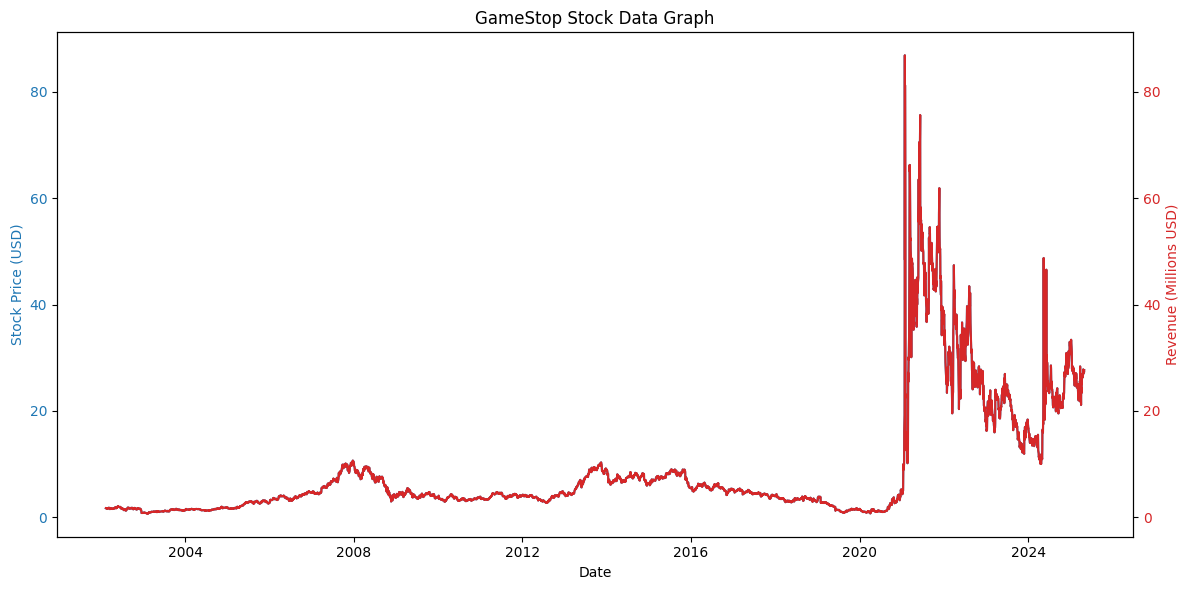

In [82]:
make_graph(gme_data, gme_revenue, 'GameStop Stock Data Graph')

GameStop's Wild Ride (2000–2025)

GameStop’s revenue stayed relatively stable over the years, reflecting its traditional retail business model. But in early 2021, the stock price exploded—fueled not by revenue, but by a viral surge in retail investor activity on Reddit. This historic short squeeze caused stock prices to skyrocket, showcasing how market momentum can defy financial fundamentals

## Author

 Jitesh Laishram